# Customer Segmentation — RFM + K-Means

Segments e-commerce customers using **Recency**, **Frequency**, **Monetary** (RFM) features and K-Means clustering.

**Dataset:** [Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) — place the file at `data/online_retail_II.xlsx`

## 1. Load & Explore

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data/online_retail_II.xlsx")
print(df.shape)
print(df.head())
print(df.dtypes)

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float

## 2. Data Cleaning

In [2]:
# Remove records with missing Customer IDs (can't segment anonymous visitors)
df = df[df['Customer ID'].notna()]

# Remove negative/zero prices (data entry errors or test records)
df = df[df['Price'] >= 0]

print(df.shape)
print(df.isnull().sum())
print(f"Zero or negative prices remaining: {(df['Price'] == 0).sum():,}")

(417534, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
Zero or negative prices remaining: 31


## 3. Feature Engineering

In [3]:
# Revenue per line item
df['Revenue'] = df['Quantity'] * df['Price']

# Flag returns (invoices starting with 'C' are cancellations)
df['Invoice'] = df['Invoice'].astype(str)
df['Return'] = np.where(df['Invoice'].str.startswith('C'), 1, 0)

In [4]:
# Aggregate to customer level: Revenue, Frequency, Returns, date range
customer_df = df.groupby('Customer ID').agg(
    Revenue=('Revenue', 'sum'),
    MinInvoiceDate=('InvoiceDate', 'min'),
    MaxInvoiceDate=('InvoiceDate', 'max'),
    Invoice=('Invoice', 'nunique'),
    Returns=('Return', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

customer_df

,Customer ID,Revenue,MinInvoiceDate,MaxInvoiceDate,Invoice,Returns
4254,18102.0,341776.73,2009-12-01 09:24:00,2010-12-09 13:44:00,95,8
1662,14646.0,243853.05,2009-12-02 16:52:00,2010-11-30 16:28:00,87,31
1291,14156.0,183180.55,2009-12-01 12:30:00,2010-12-03 11:48:00,138,62
1869,14911.0,137675.91,2009-12-01 11:41:00,2010-12-09 12:17:00,270,140
957,13694.0,128172.42,2009-12-04 15:26:00,2010-12-01 12:12:00,105,16
...,...,...,...,...,...,...
3392,16981.0,-4620.86,2010-06-17 15:49:00,2010-06-17 15:49:00,1,1
2478,15760.0,-5795.87,2010-03-19 11:30:00,2010-03-19 11:53:00,5,3
2540,15849.0,-5876.34,2010-04-22 12:55:00,2010-04-22 12:55:00,1,1
378,12918.0,-10953.50,2010-03-23 15:20:00,2010-03-23 15:24:00,3,2


In [5]:
# Loyalty = number of days between first and last order
customer_df['loyalty'] = (customer_df['MaxInvoiceDate'] - customer_df['MinInvoiceDate']).dt.days

# Recency = days since last order (lower = more recent)
reference_date = df['InvoiceDate'].max()
customer_df['Recency'] = (reference_date - customer_df['MaxInvoiceDate']).dt.days
customer_df.rename(columns={'Invoice': 'Frequency'}, inplace=True)

customer_df

,Customer ID,Revenue,MinInvoiceDate,MaxInvoiceDate,Frequency,Returns,loyalty,Recency
4254,18102.0,341776.73,2009-12-01 09:24:00,2010-12-09 13:44:00,95,8,373,0
1662,14646.0,243853.05,2009-12-02 16:52:00,2010-11-30 16:28:00,87,31,362,9
1291,14156.0,183180.55,2009-12-01 12:30:00,2010-12-03 11:48:00,138,62,366,6
1869,14911.0,137675.91,2009-12-01 11:41:00,2010-12-09 12:17:00,270,140,373,0
957,13694.0,128172.42,2009-12-04 15:26:00,2010-12-01 12:12:00,105,16,361,8
...,...,...,...,...,...,...,...,...
3392,16981.0,-4620.86,2010-06-17 15:49:00,2010-06-17 15:49:00,1,1,0,175
2478,15760.0,-5795.87,2010-03-19 11:30:00,2010-03-19 11:53:00,5,3,0,265
2540,15849.0,-5876.34,2010-04-22 12:55:00,2010-04-22 12:55:00,1,1,0,231
378,12918.0,-10953.50,2010-03-23 15:20:00,2010-03-23 15:24:00,3,2,0,261


## 4. Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

df_classification = customer_df.drop(columns=['MinInvoiceDate', 'MaxInvoiceDate'])
print(df_classification.columns)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_classification.drop(columns=['Customer ID']))

Index(['Customer ID', 'Revenue', 'Frequency', 'Returns', 'loyalty', 'Recency'], dtype='object')


## 5. Find Optimal Number of Clusters (Elbow Method)

/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python

/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python

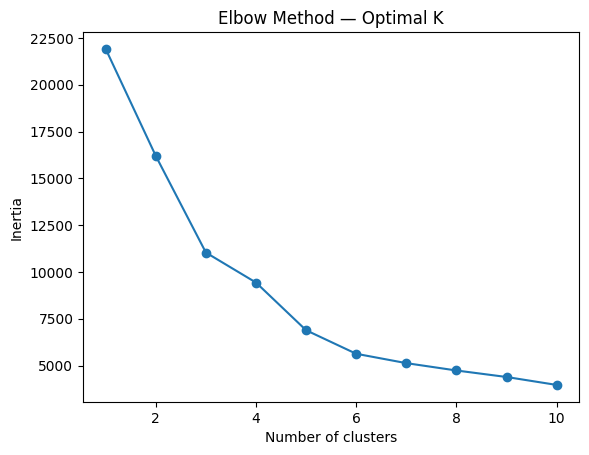

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## 6. Train Final K-Means Model

In [8]:
# Train with 4 clusters (identified from elbow plot)
model = KMeans(n_clusters=4, random_state=42).fit(rfm_scaled)
customer_df['Cluster'] = model.labels_
customer_df['Cluster'].value_counts()

/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python

Cluster
0    1808
3    1577
1     991
2       7
Name: count, dtype: int64

## 7. Visualise Segments

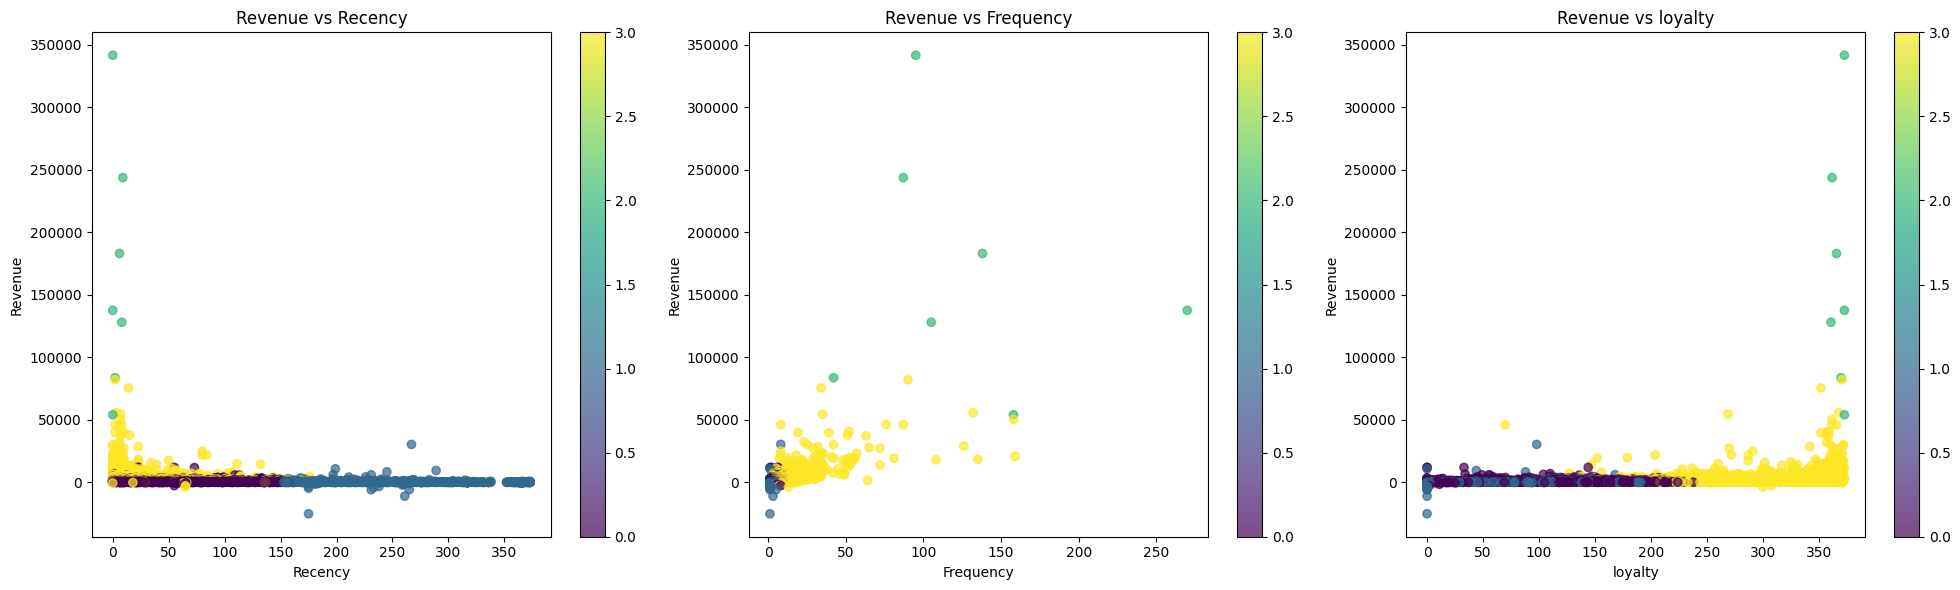

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, x_col in zip(axes, ['Recency', 'Frequency', 'loyalty']):
    sc = ax.scatter(customer_df[x_col], customer_df['Revenue'],
                    c=customer_df['Cluster'], cmap='viridis', alpha=0.7)
    ax.set_xlabel(x_col)
    ax.set_ylabel('Revenue')
    ax.set_title(f'Revenue vs {x_col}')
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

In [10]:
# Average metrics per cluster to interpret the segments
customer_df.groupby('Cluster').agg({
    'Revenue': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean',
    'loyalty': 'mean'
}).round(1)

,Revenue,Frequency,Recency,loyalty
Cluster,,,,
0,729.4,2.5,53.9,60.1
1,381.1,1.8,251.4,25.4
2,167501.9,127.9,3.6,368.3
3,3474.5,10.4,31.5,294.0


## 8. Label Clusters

In [11]:
cluster_names = {
    0: 'Loyal regulars',
    1: 'Lost',
    2: 'Champions',
    3: 'At risk'
}

customer_df['Cluster Name'] = customer_df['Cluster'].map(cluster_names)
customer_df

,Customer ID,Revenue,MinInvoiceDate,MaxInvoiceDate,Frequency,Returns,loyalty,Recency,Cluster,Cluster Name
4254,18102.0,341776.73,2009-12-01 09:24:00,2010-12-09 13:44:00,95,8,373,0,2,Champions
1662,14646.0,243853.05,2009-12-02 16:52:00,2010-11-30 16:28:00,87,31,362,9,2,Champions
1291,14156.0,183180.55,2009-12-01 12:30:00,2010-12-03 11:48:00,138,62,366,6,2,Champions
1869,14911.0,137675.91,2009-12-01 11:41:00,2010-12-09 12:17:00,270,140,373,0,2,Champions
957,13694.0,128172.42,2009-12-04 15:26:00,2010-12-01 12:12:00,105,16,361,8,2,Champions
...,...,...,...,...,...,...,...,...,...,...
3392,16981.0,-4620.86,2010-06-17 15:49:00,2010-06-17 15:49:00,1,1,0,175,1,Lost
2478,15760.0,-5795.87,2010-03-19 11:30:00,2010-03-19 11:53:00,5,3,0,265,1,Lost
2540,15849.0,-5876.34,2010-04-22 12:55:00,2010-04-22 12:55:00,1,1,0,231,1,Lost
378,12918.0,-10953.50,2010-03-23 15:20:00,2010-03-23 15:24:00,3,2,0,261,1,Lost


In [12]:
# Save segmented customers for use in churn prediction notebook
customer_df.to_csv('data/customer_segments.csv', index=False)
print("Saved to data/customer_segments.csv")

Saved to data/customer_segments.csv
